# Week 2 - Day 4: Exploratory Data Analysis (EDA)

This notebook performs a hands-on EDA on the music dataset.

**Step 1 — Load dataset**

We load `data.csv` from the notebook directory and remove the unnecessary `Unnamed: 0` index column if present.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.shape

(2017, 16)

**Step 2 — Inspect the data**

Use `shape`, `head()`, `info()` and `describe()` to understand the dataset structure and basic statistics.

In [2]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Shape: (2017, 16)
Columns: ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'target', 'song_title', 'artist']


,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,target,song_title,artist
0,0.0102,0.833,204600,0.434,0.021900,2,0.1650,-8.795,1,0.4310,150.062,4.0,0.286,1,Mask Off,Future
1,0.1990,0.743,326933,0.359,0.006110,1,0.1370,-10.401,1,0.0794,160.083,4.0,0.588,1,Redbone,Childish Gambino
2,0.0344,0.838,185707,0.412,0.000234,2,0.1590,-7.148,1,0.2890,75.044,4.0,0.173,1,Xanny Family,Future
3,0.6040,0.494,199413,0.338,0.510000,5,0.0922,-15.236,1,0.0261,86.468,4.0,0.230,1,Master Of None,Beach House
4,0.1800,0.678,392893,0.561,0.512000,5,0.4390,-11.648,0,0.0694,174.004,4.0,0.904,1,Parallel Lines,Junior Boys


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2017 entries, 0 to 2016
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      2017 non-null   float64
 1   danceability      2017 non-null   float64
 2   duration_ms       2017 non-null   int64  
 3   energy            2017 non-null   float64
 4   instrumentalness  2017 non-null   float64
 5   key               2017 non-null   int64  
 6   liveness          2017 non-null   float64
 7   loudness          2017 non-null   float64
 8   mode              2017 non-null   int64  
 9   speechiness       2017 non-null   float64
 10  tempo             2017 non-null   float64
 11  time_signature    2017 non-null   float64
 12  valence           2017 non-null   float64
 13  target            2017 non-null   int64  
 14  song_title        2017 non-null   str    
 15  artist            2017 non-null   str    
dtypes: float64(10), int64(4), str(2)
memory usage: 252.3 

In [4]:
df.select_dtypes(include=["number"]).describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,target
count,2017.000000,2017.000000,2.017000e+03,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000
mean,0.187590,0.618422,2.463062e+05,0.681577,0.133286,5.342588,0.190844,-7.085624,0.612295,0.092664,121.603272,3.968270,0.496815,0.505702
std,0.259989,0.161029,8.198181e+04,0.210273,0.273162,3.648240,0.155453,3.761684,0.487347,0.089931,26.685604,0.255853,0.247195,0.500091
min,0.000003,0.122000,1.604200e+04,0.014800,0.000000,0.000000,0.018800,-33.097000,0.000000,0.023100,47.859000,1.000000,0.034800,0.000000
25%,0.009630,0.514000,2.000150e+05,0.563000,0.000000,2.000000,0.092300,-8.394000,0.000000,0.037500,100.189000,4.000000,0.295000,0.000000
50%,0.063300,0.631000,2.292610e+05,0.715000,0.000076,6.000000,0.127000,-6.248000,1.000000,0.054900,121.427000,4.000000,0.492000,1.000000
75%,0.265000,0.738000,2.703330e+05,0.846000,0.054000,9.000000,0.247000,-4.746000,1.000000,0.108000,137.849000,4.000000,0.691000,1.000000
max,0.995000,0.984000,1.004627e+06,0.998000,0.976000,11.000000,0.969000,-0.307000,1.000000,0.816000,219.331000,5.000000,0.992000,1.000000


**Step 3 — Missing values and duplicates**

Check missing values and duplicated rows, then remove duplicated observations before continuing the analysis.

In [5]:
print("Missing values:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print("\nDuplicate rows before cleaning:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

Missing values:
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
target              0
song_title          0
artist              0
dtype: int64

Duplicate rows before cleaning: 5
Duplicate rows after cleaning: 0
Dataset shape after cleaning: (2012, 16)


### Duplicate Handling

The dataset initially contained 5 duplicated rows. These rows were removed because they repeated complete observations and did not add new information.

**Target distribution**

Visualize the `target` column to inspect the balance between the two classes.

target
1    1015
0     997
Name: count, dtype: int64


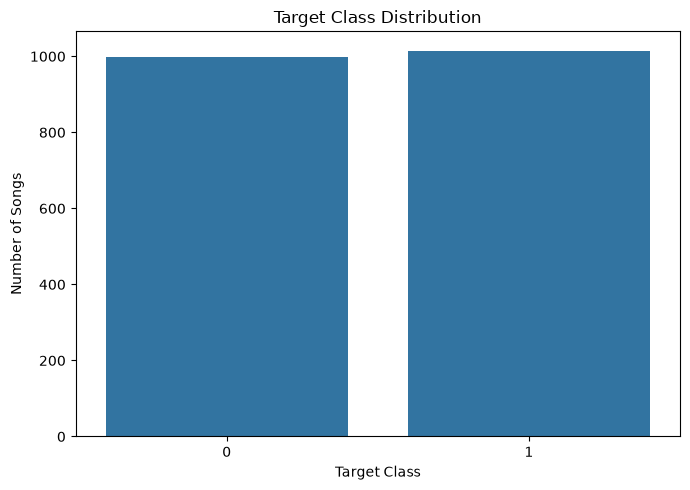

In [6]:
print(df["target"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="target")
plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

**Result — Target distribution**

The two target classes are approximately balanced after removing the duplicated rows. This reduces the risk of a future model becoming strongly biased toward one class.

**Step 4 — Univariate analysis**

Use histograms to examine the distributions of important numerical features.

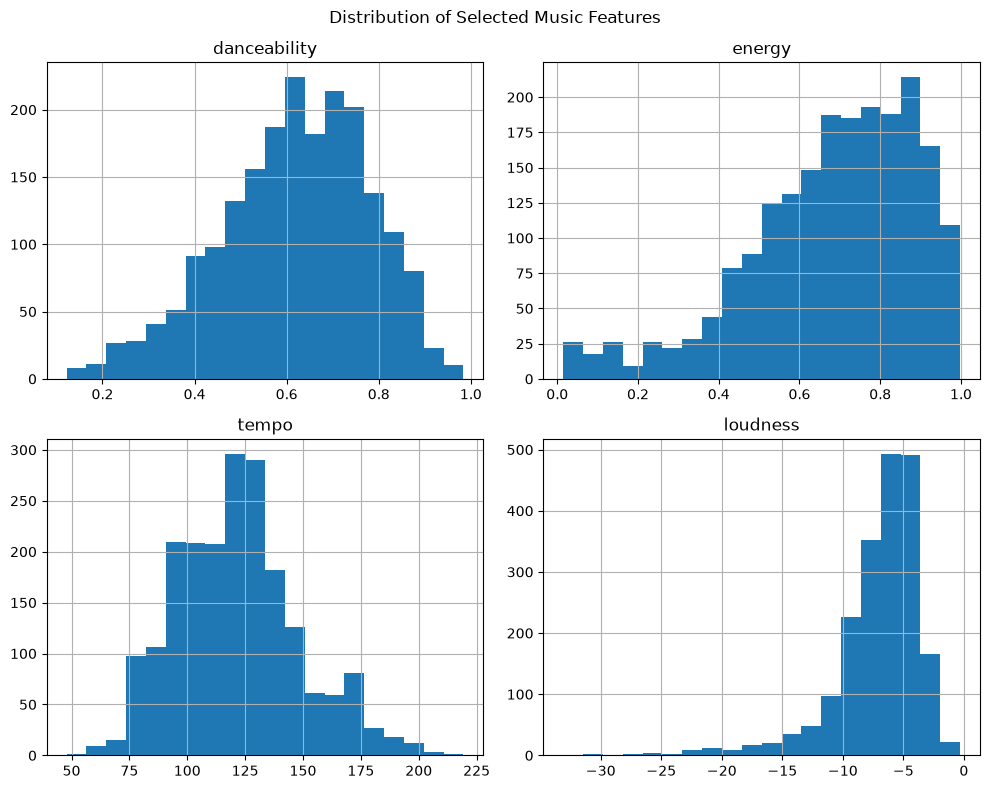

In [7]:
df[
    ["danceability", "energy", "tempo", "loudness"]
].hist(figsize=(10, 8), bins=20)

plt.suptitle("Distribution of Selected Music Features")
plt.tight_layout()
plt.show()

**Result — Histograms**

- Most `danceability` values are concentrated in the middle and upper ranges.
- `energy` is mainly concentrated around medium-to-high values.
- `loudness` values are concentrated within a relatively limited negative range.
- `tempo` has a wider distribution and contains a small number of extreme values.
- The selected features do not all have the same distribution shape.

**Tempo box plot**

Use a box plot to visualize the center, spread, and potential tempo outliers.

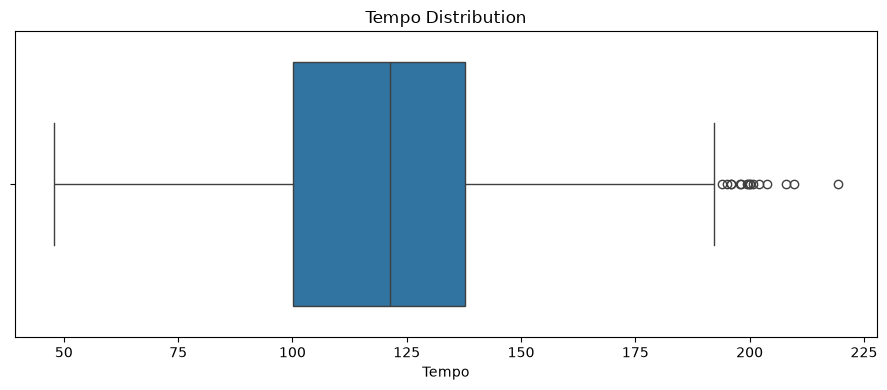

In [8]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x="tempo")
plt.title("Tempo Distribution")
plt.xlabel("Tempo")
plt.tight_layout()
plt.show()

**IQR outlier detection for tempo**

Calculate the IQR bounds and identify potential tempo outliers.

In [9]:
q1 = df["tempo"].quantile(0.25)
q3 = df["tempo"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[
    (df["tempo"] < lower) |
    (df["tempo"] > upper)
]

outlier_percentage = len(outliers) / len(df) * 100

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of tempo outliers:", len(outliers))
print("Outlier percentage:", round(outlier_percentage, 2), "%")

Q1: 100.16399999999999
Q3: 137.69525
IQR: 37.53125
Lower bound: 43.86712499999999
Upper bound: 193.992125
Number of tempo outliers: 16
Outlier percentage: 0.8 %


**Decision on tempo outliers**

The IQR method detected 16 potential tempo outliers, representing approximately 0.8% of the cleaned dataset. These values will not be removed because unusually low or high tempo values may represent valid songs rather than data-entry errors.

**Bivariate analysis — Energy vs Loudness**

Examine the relationship between energy and loudness.

Energy and loudness correlation: 0.76


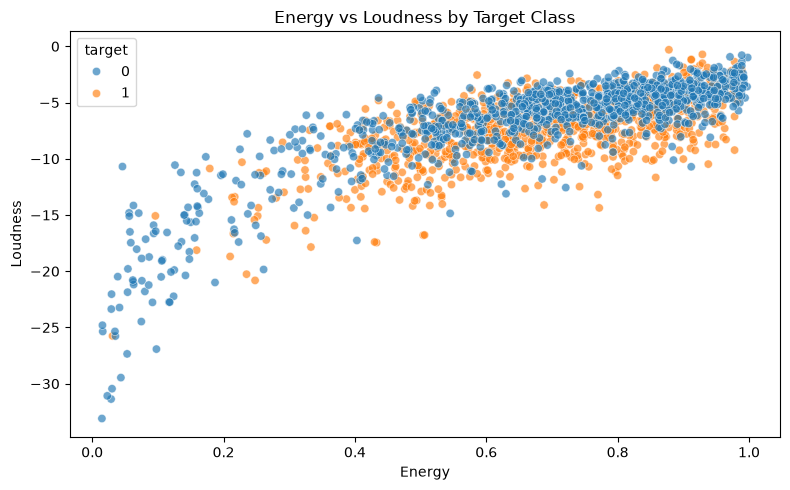

In [10]:
energy_loudness_correlation = df[
    ["energy", "loudness"]
].corr().loc["energy", "loudness"]

print(
    "Energy and loudness correlation:",
    round(energy_loudness_correlation, 2)
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="energy",
    y="loudness",
    hue="target",
    alpha=0.65
)

plt.title("Energy vs Loudness by Target Class")
plt.xlabel("Energy")
plt.ylabel("Loudness")
plt.tight_layout()
plt.show()

**Result — Energy vs Loudness**

`energy` and `loudness` have a strong positive correlation of approximately 0.76. Songs with higher energy generally tend to be louder, although the two target classes still overlap.

**Bivariate analysis — Energy by Target Class**

Compare the energy distribution between the two target classes.

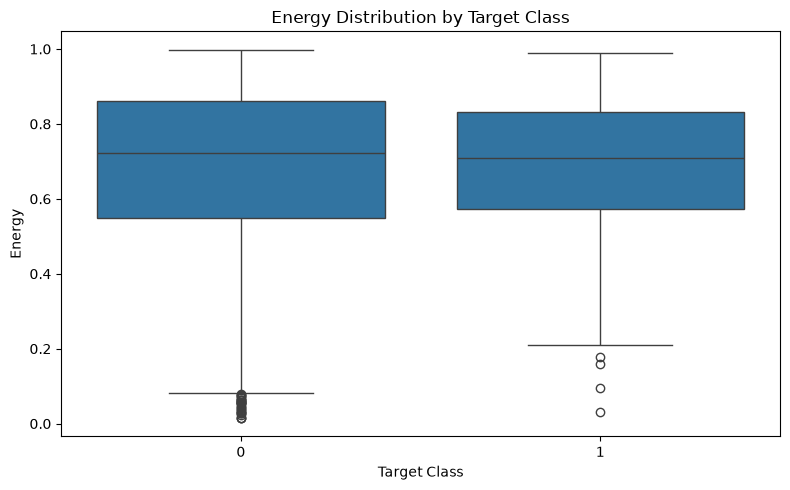

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="target",
    y="energy"
)

plt.title("Energy Distribution by Target Class")
plt.xlabel("Target Class")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

**Result — Energy by Target Class**

The energy distributions of the two target classes overlap considerably. Any difference in their medians may provide some useful information, but energy alone is not enough to separate the classes.

**Bivariate analysis — Danceability vs Valence**

Examine the relationship between danceability and valence across the target classes.

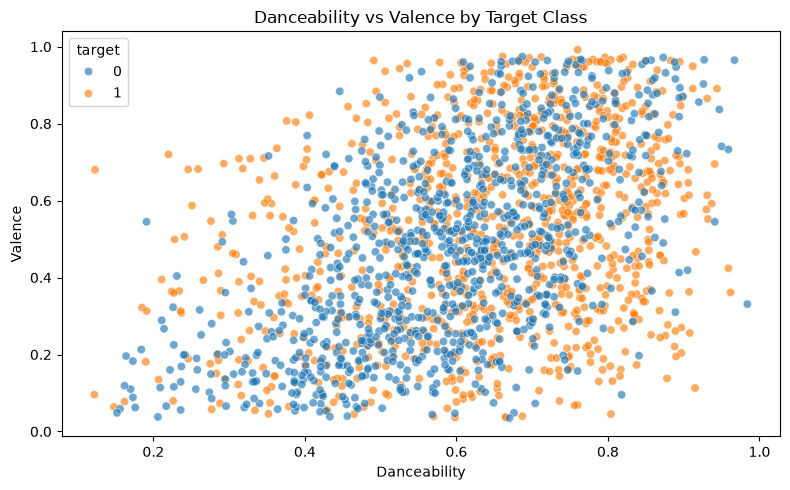

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="danceability",
    y="valence",
    hue="target",
    alpha=0.65
)

plt.title("Danceability vs Valence by Target Class")
plt.xlabel("Danceability")
plt.ylabel("Valence")
plt.tight_layout()
plt.show()

**Result — Danceability vs Valence**

The plot shows considerable overlap between the target classes. Danceability and valence may provide some information together, but they are unlikely to separate the classes perfectly on their own.

**Multivariate analysis — Correlation heatmap**

Calculate the correlation matrix for the numerical features and visualize it using a heatmap.

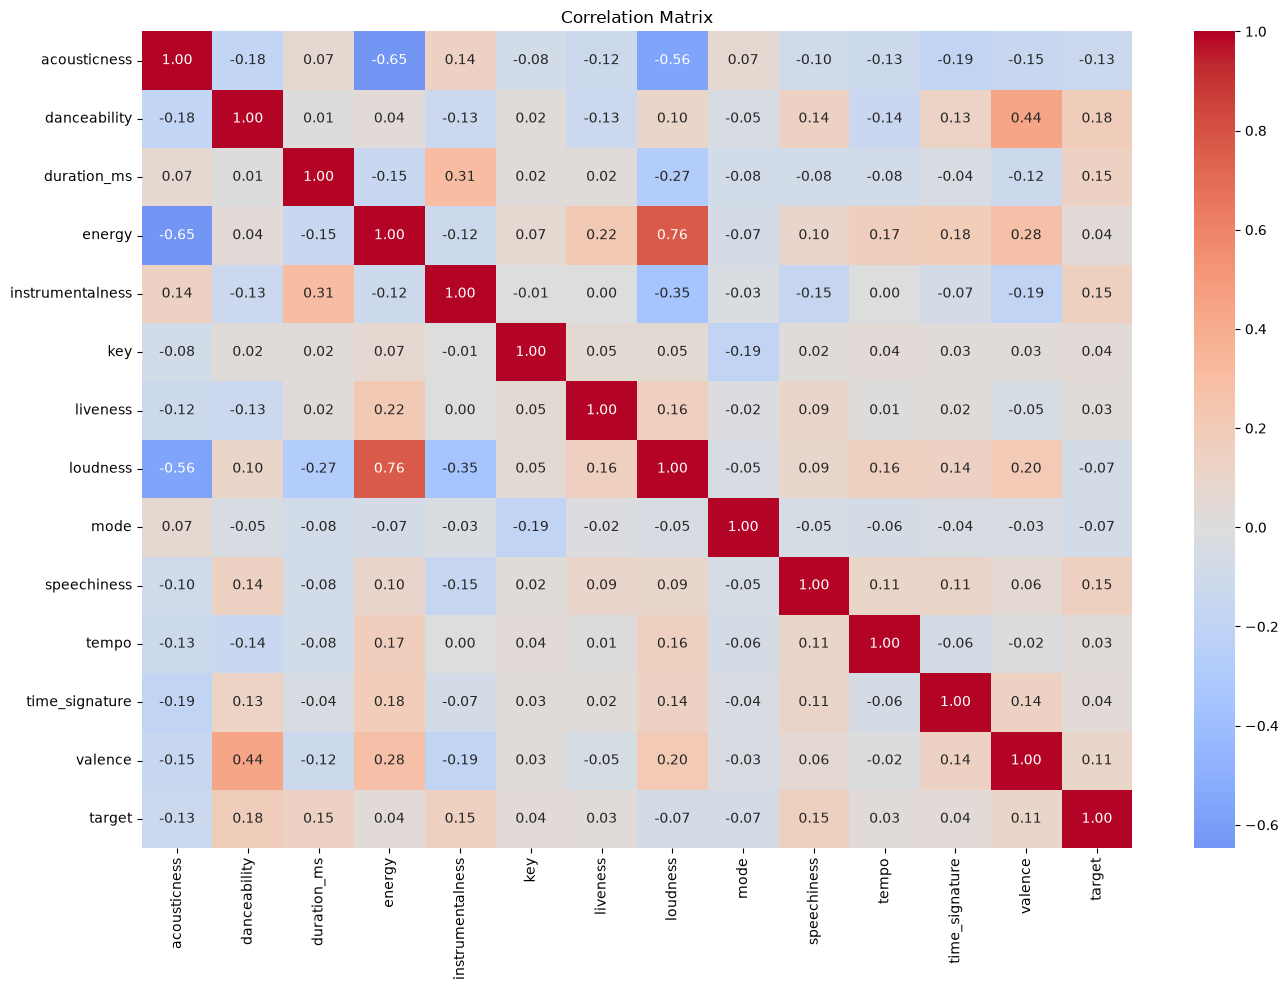

In [13]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Strongest correlation pairs**

Extract the strongest unique correlations instead of relying only on visual inspection.

In [14]:
upper_triangle = corr.where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

strongest_pairs = (
    upper_triangle
    .stack()
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

print("Strongest correlation pairs:")
print(strongest_pairs.head(5))

Strongest correlation pairs:
energy            loudness    0.762286
acousticness      energy     -0.647216
                  loudness   -0.561311
danceability      valence     0.442092
instrumentalness  loudness   -0.353337
dtype: float64


## Strongest Correlation Relationships

- `energy` and `loudness` have the strongest positive correlation, with a value of approximately `0.76`. Songs with higher energy generally tend to be louder.
- `acousticness` and `energy` have a strong negative correlation of approximately `-0.65`. More acoustic songs generally tend to have lower energy.
- `acousticness` and `loudness` have a negative correlation of approximately `-0.56`. Songs with higher acousticness tend to be quieter.
- `danceability` and `valence` have a moderate positive correlation of approximately `0.44`.

The correlations with `target` are generally weak. The highest positive correlation with the target is for `danceability` at approximately `0.18`. This suggests that no single feature is sufficient to distinguish the target classes.

Correlation shows association between variables, but it does not prove causation.

## Final EDA Conclusions

- The dataset contains no missing values in the analyzed columns.
- Five duplicated rows were identified and removed before continuing the analysis.
- The target classes remain approximately balanced after cleaning.
- The numerical features have different distribution shapes.
- For `tempo`, Q1 is approximately `100.16`, Q3 is `137.70`, and the IQR is `37.53`.
- Tempo values below `43.87` or above `193.99` were identified as potential outliers.
- A total of `16` tempo outliers were detected, representing approximately `0.8%` of the cleaned dataset.
- These outliers were retained because unusual tempo values may represent real songs rather than data-entry errors.
- The strongest positive relationship is between `energy` and `loudness`, with a correlation of approximately `0.76`.
- `acousticness` has strong negative relationships with both `energy` and `loudness`.
- The relationships with `target` are weak, so a future model should combine several features rather than depend on one variable.

Overall, the dataset is suitable for the next analysis stage after removing duplicated rows. Correlation can support feature selection, but it does not prove causation.